# 🩺 Diabetes Dataset - EDA
**Day 1 - AI Internship** | Libraries: Pandas, Matplotlib, Seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import sklearn.metrics as metr


We import all the libraries we need upfront. pandas handles tabular data, numpy handles math/arrays, matplotlib and seaborn handle visualizations, and sklearn.metrics will be used later for model evaluation.

In [3]:
from google.colab import files
up=files.upload()

Saving diabetes.csv to diabetes.csv


In [4]:
df=pd.read_csv("diabetes.csv")

We upload the CSV file from our local machine using Colab's file uploader, then load it into a DataFrame called df. A DataFrame is like a table — rows are patients, columns are features like Glucose, BMI, etc.

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0



head() shows the first five rows so we can see the column names and data types at a glance. tail() shows the last 5 rows to confirm the data loads correctly all the way to the end.

In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


This checks how many missing values exist in each column. Missing data can break machine learning models, so identifying them early is a critical step in any EDA. Here we find 0 nulls — but some columns like Glucose have 0 as a value, which is biologically impossible and should be investigated further.

In [8]:
df.size


6912

In [9]:
df.shape

(768, 9)

df.size gives total number of cells (rows × columns). df.dropna() removes rows with null values — since we have none, size stays the same. df.shape gives (768, 9) meaning 768 patients and 9 columns. This confirms we have a complete dataset.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


info() shows data types and memory usage.


In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


describe() gives statistics like mean, min, max, and standard deviation for every column — very useful to spot outliers.

In [12]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


dtypes confirms all columns are numeric (float64/int64), which is required for most ML algorithms.

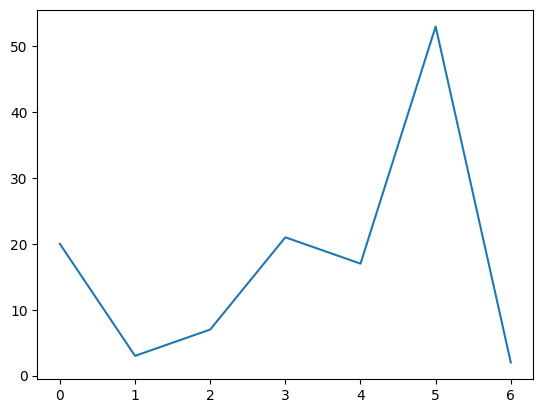

In [13]:
x=[20,3,7,21,17,53,2]
plt.plot(x)

Practice plotting with a small custom array first. Both a numpy array and a plain Python list work with plt.plot(). This line plot just connects the values in sequence — useful for understanding how the function works before applying it to real data.

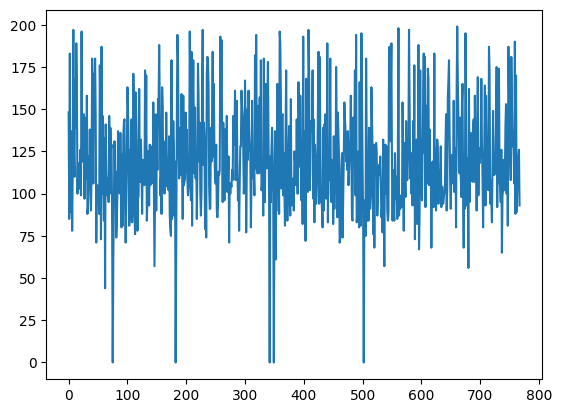

In [14]:
plt.plot(df['Glucose'])

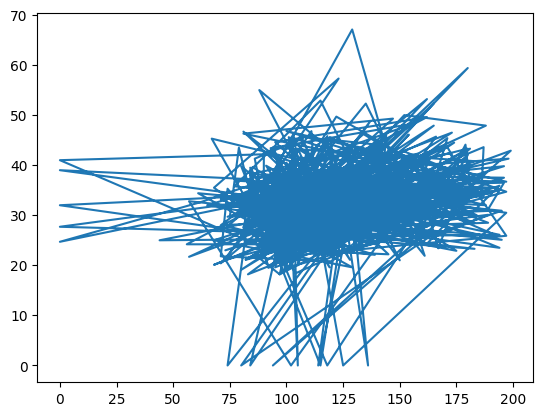

In [15]:
plt.plot(df['Glucose'],df['BMI'])
plt.show()

Text(0, 0.5, 'Insulin')

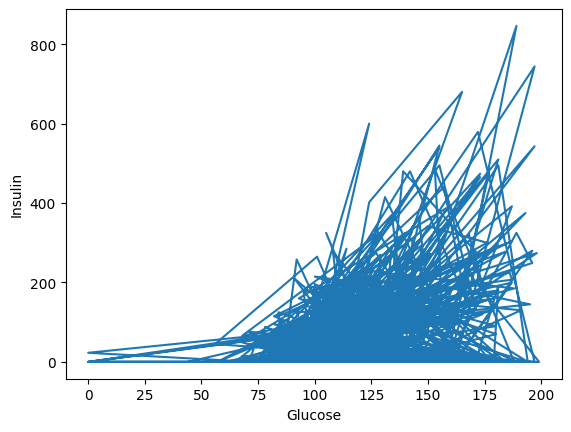

In [16]:
plt.plot(df['Glucose'],df['Insulin'])
plt.xlabel('Glucose')
plt.ylabel('Insulin')

When two columns are passed to plt.plot(), it draws a line connecting each (x, y) pair in row order — this creates a messy criss-cross. A scatter plot (below) is better for showing relationships between two variables. Always add axis labels so the chart is readable.

<Axes: xlabel='BloodPressure'>

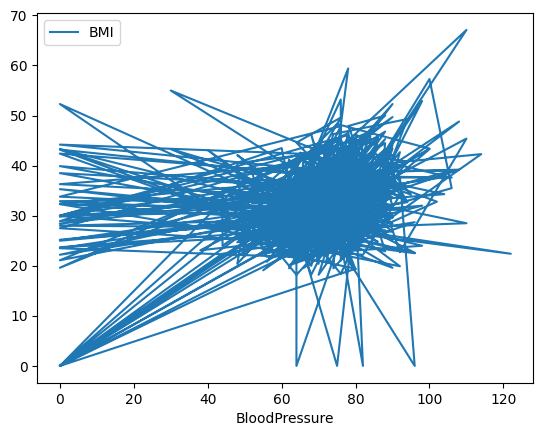

In [17]:
df.plot(x='BloodPressure',y='BMI')



Pandas has its own built-in .plot() method that wraps matplotlib. This is a convenient shortcut — you don't need to type df['column'] separately. It creates a line plot of BMI against BloodPressure values.

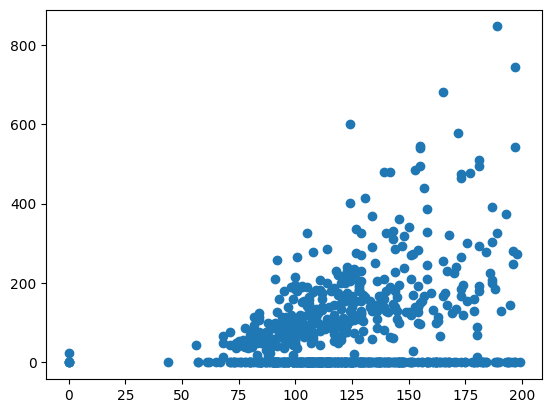

In [18]:
plt.scatter(df['Glucose'],df['Insulin'])

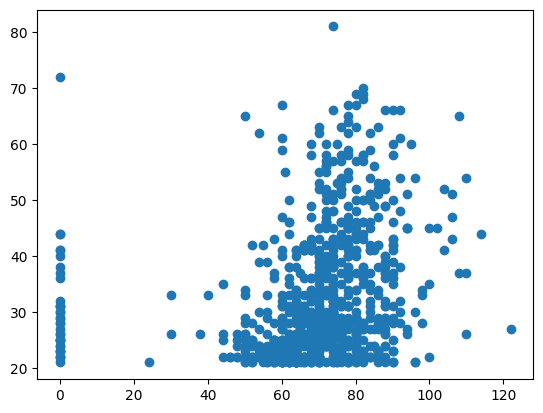

In [19]:
plt.scatter(df['BloodPressure'],df['Age'])

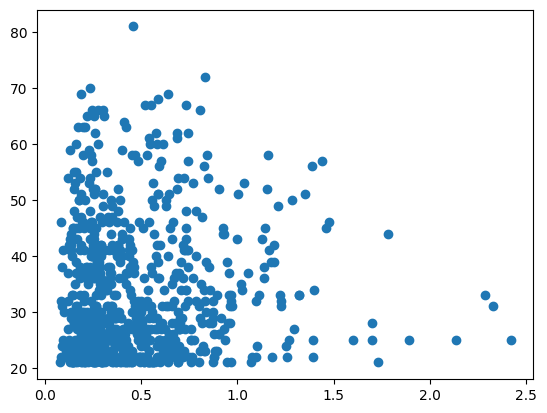

In [20]:
plt.scatter(df['DiabetesPedigreeFunction'],df['Age'])


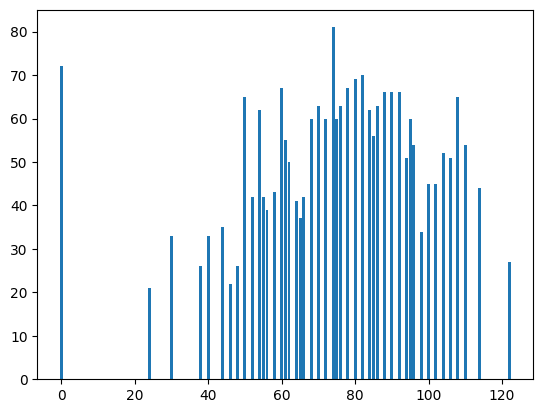

In [21]:
plt.bar(df['BloodPressure'],df['Age'])
plt.show()



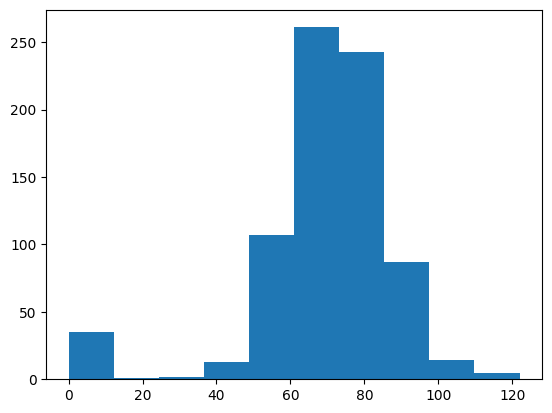

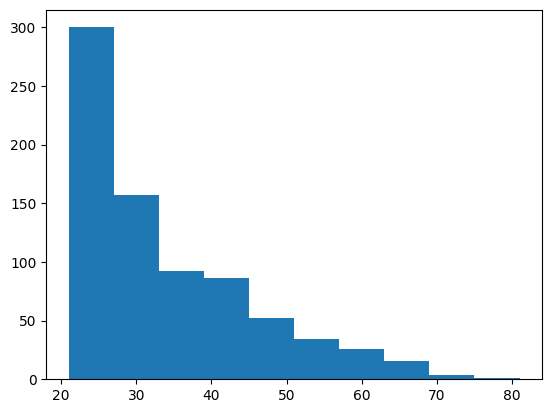

In [22]:
plt.hist(df['BloodPressure'])#normal distribution
plt.show()
plt.hist(df['Age'])  # right skewed
plt.show()

(array([300., 157.,  92.,  86.,  52.,  34.,  26.,  16.,   4.,   1.]),
 array([21., 27., 33., 39., 45., 51., 57., 63., 69., 75., 81.]),
 <BarContainer object of 10 artists>)

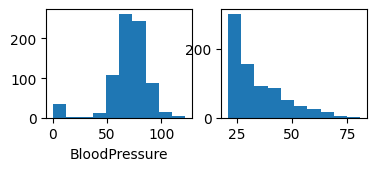

In [23]:
plt.subplot(331)
plt.hist(df['BloodPressure'])#normal distribution
plt.xlabel("BloodPressure")
plt.subplot(332)
plt.hist(df['Age'])

plt.subplot(331) means a 3×3 grid, position 1. This lets us show multiple plots side by side in one figure. Much cleaner than running separate plots. Always add plt.tight_layout() at the end to prevent titles and labels from overlapping.

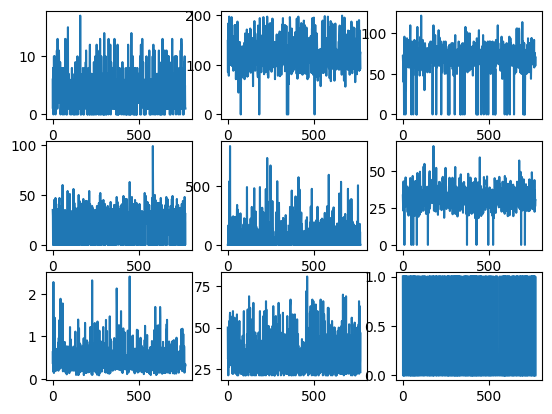

In [24]:
cl=df.columns.tolist()
for i in range(len(cl)):
  plt.subplot(3,3,i+1)
  plt.plot(df[cl[i]])


We use a loop to automatically plot all 9 columns in a 3×3 grid — no need to write a plt.plot() line for each. df.columns.tolist() gives us ['Pregnancies', 'Glucose', 'BloodPressure', ...] and the loop plots each one in its own subplot panel.

([<matplotlib.patches.Wedge at 0x7de192364f20>,
 [Text(1.099924423307751, 0.012894301497614658, ''),
  Text(1.0996977036161613, 0.025786831161309223, ''),
  Text(1.099319872043255, 0.038675818424456554, ''),
  Text(1.098790980615742, 0.05155948911205349, ''),
  Text(1.0981111019616967, 0.06443607489961047, ''),
  Text(1.0972803292167246, 0.07730381047553045, ''),
  Text(1.0962987767312378, 0.09016092356221597, ''),
  Text(1.0951665801500075, 0.10300563927541805, ''),
  Text(1.093883894474538, 0.11583620077168452, ''),
  Text(1.0908677804677267, 0.1414478191327662, ''),
  Text(1.089134765247206, 0.15422536474235876, ''),
  Text(1.0872520918842858, 0.16698170167190404, ''),
  Text(1.085220014295288, 0.17971510947311997, ''),
  Text(1.0830388168783618, 0.1924238060498711, ''),
  Text(1.0782302679476312, 0.21776016458842898, ''),
  Text(1.0728291013685773, 0.24297678748532964, ''),
  Text(1.066838261197484, 0.2680599269662082, ''),
  Text(1.06026107063193, 0.29299566908477304, ''),
  Text(

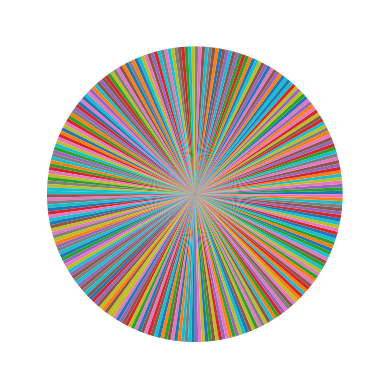

In [25]:
plt.pie(df['Outcome'])

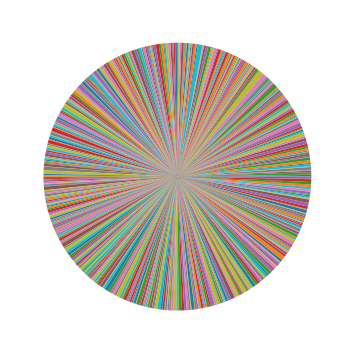

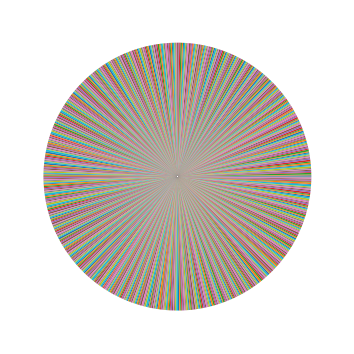

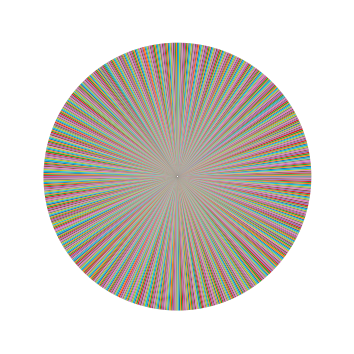

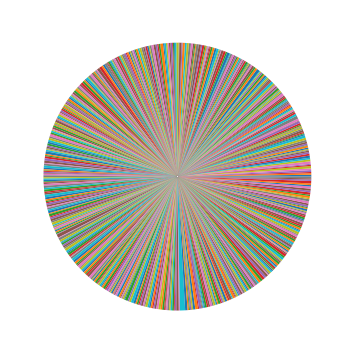

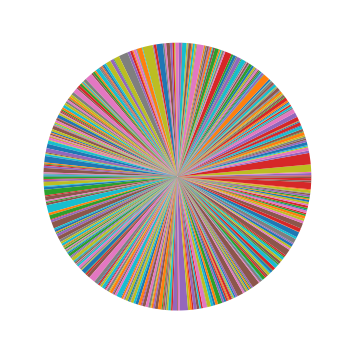

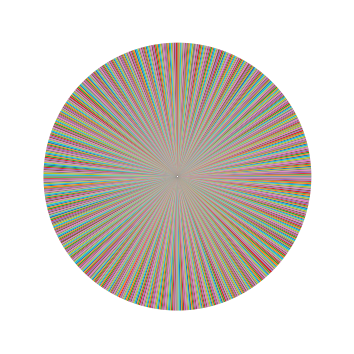

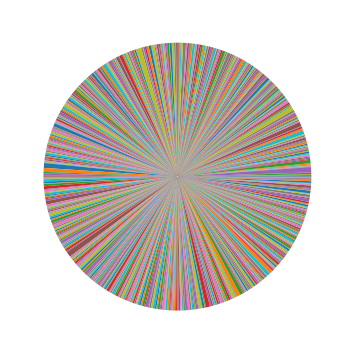

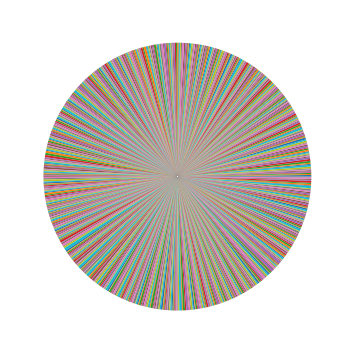

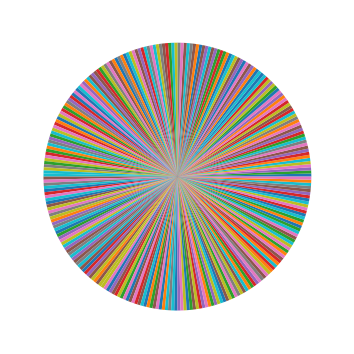

In [26]:
for i in range(len(cl)):
  plt.figure(figsize=(20,20))
  plt.subplot(4,3,i+1)
  plt.pie(df[cl[i]])

<Axes: ylabel='SkinThickness'>

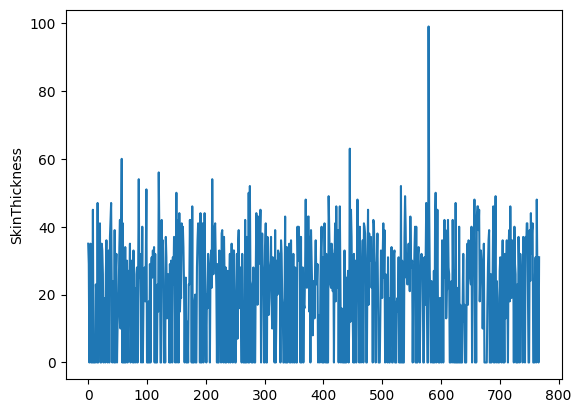

In [27]:
sn.lineplot(df['SkinThickness'])

<Axes: xlabel='BMI', ylabel='Age'>

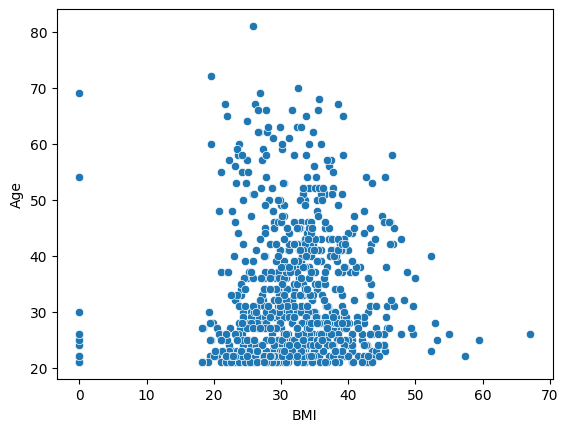

In [28]:
sn.scatterplot(x=df['BMI'],y=df['Age'],data=df)

<Axes: xlabel='BMI', ylabel='DiabetesPedigreeFunction'>

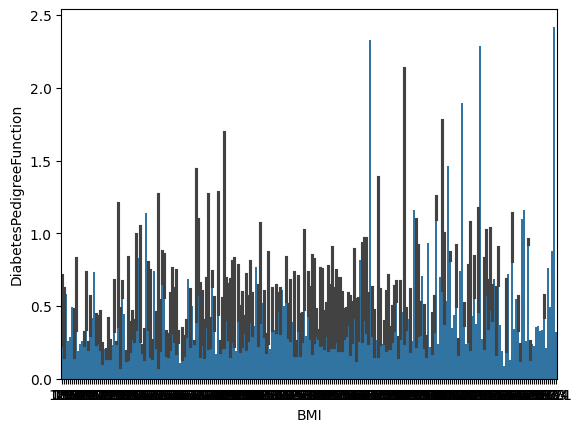

In [29]:
sn.barplot(x=df['BMI'],y=df['DiabetesPedigreeFunction'],data=df)

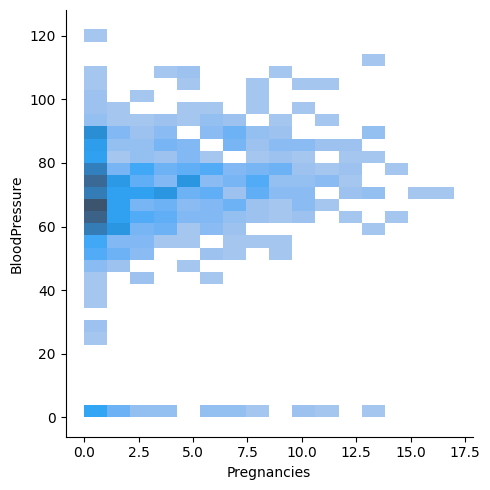

In [30]:
sn.displot(x=df['Pregnancies'],y=df['BloodPressure'],data=df)

/tmp/ipykernel_6076/1911665114.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sn.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

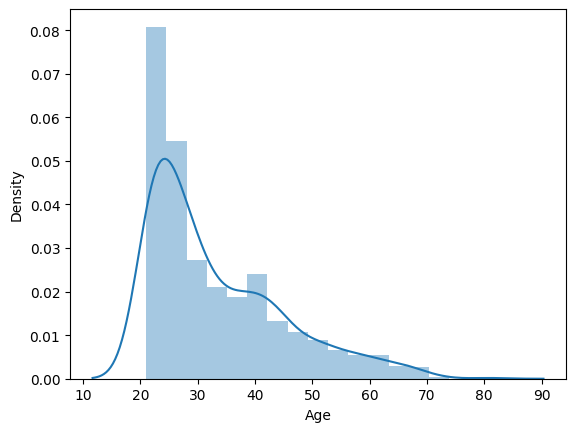

In [31]:
sn.distplot(df['Age'])

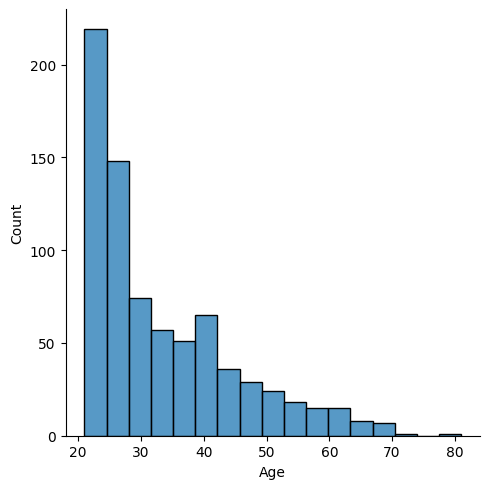

In [32]:
sn.displot(df['Age'])

/tmp/ipykernel_6076/1911665114.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sn.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

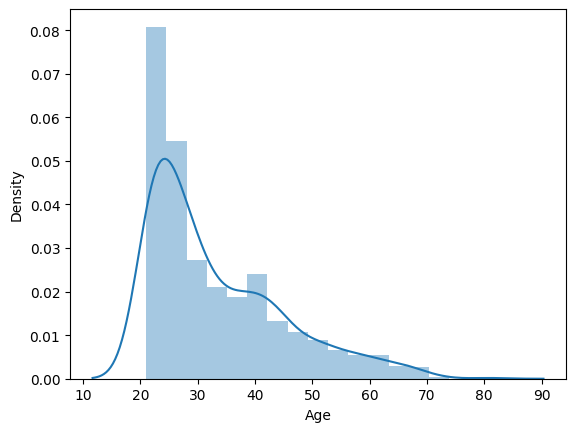

In [33]:
sn.distplot(df['Age'])

displot is the modern replacement for distplot (which is deprecated and will be removed). displot shows the distribution of a variable as a histogram with an optional KDE (smooth curve) overlay. The 2D version with x and y shows a joint distribution as a density heatmap.

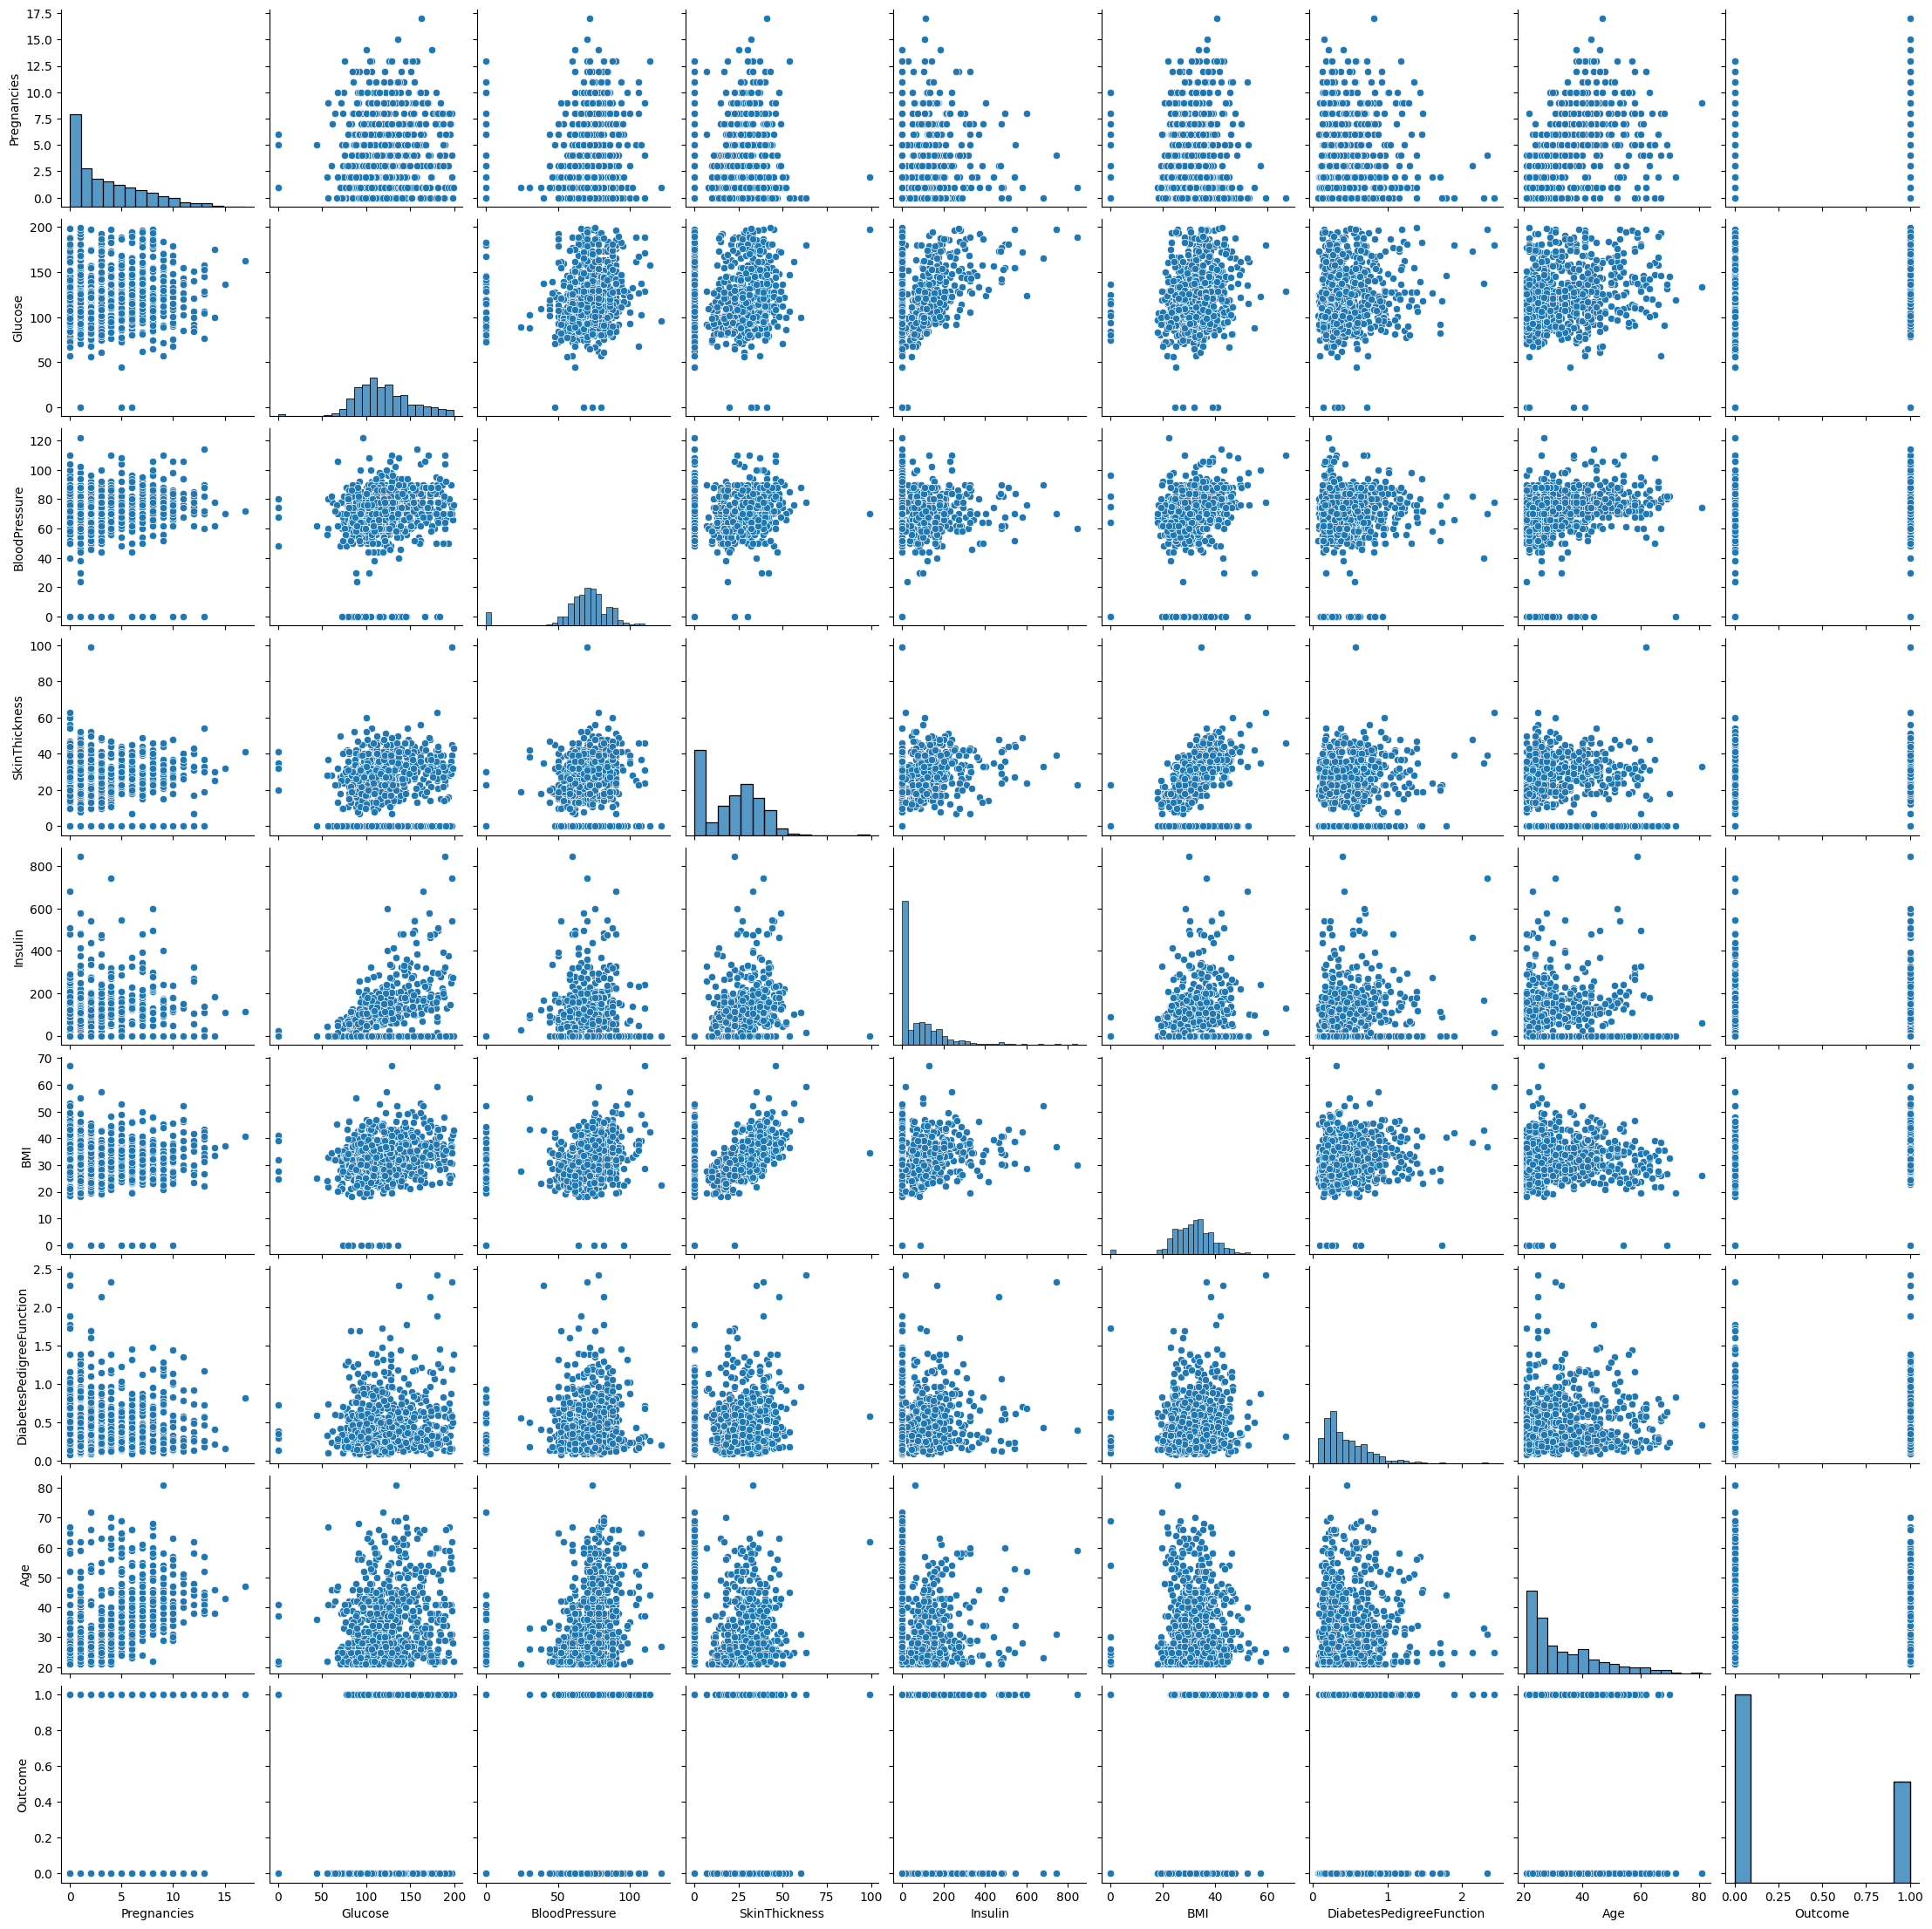

In [34]:
sn.pairplot(df)


pairplot is one of the most powerful EDA tools — it creates a grid of scatter plots for every pair of columns at once.

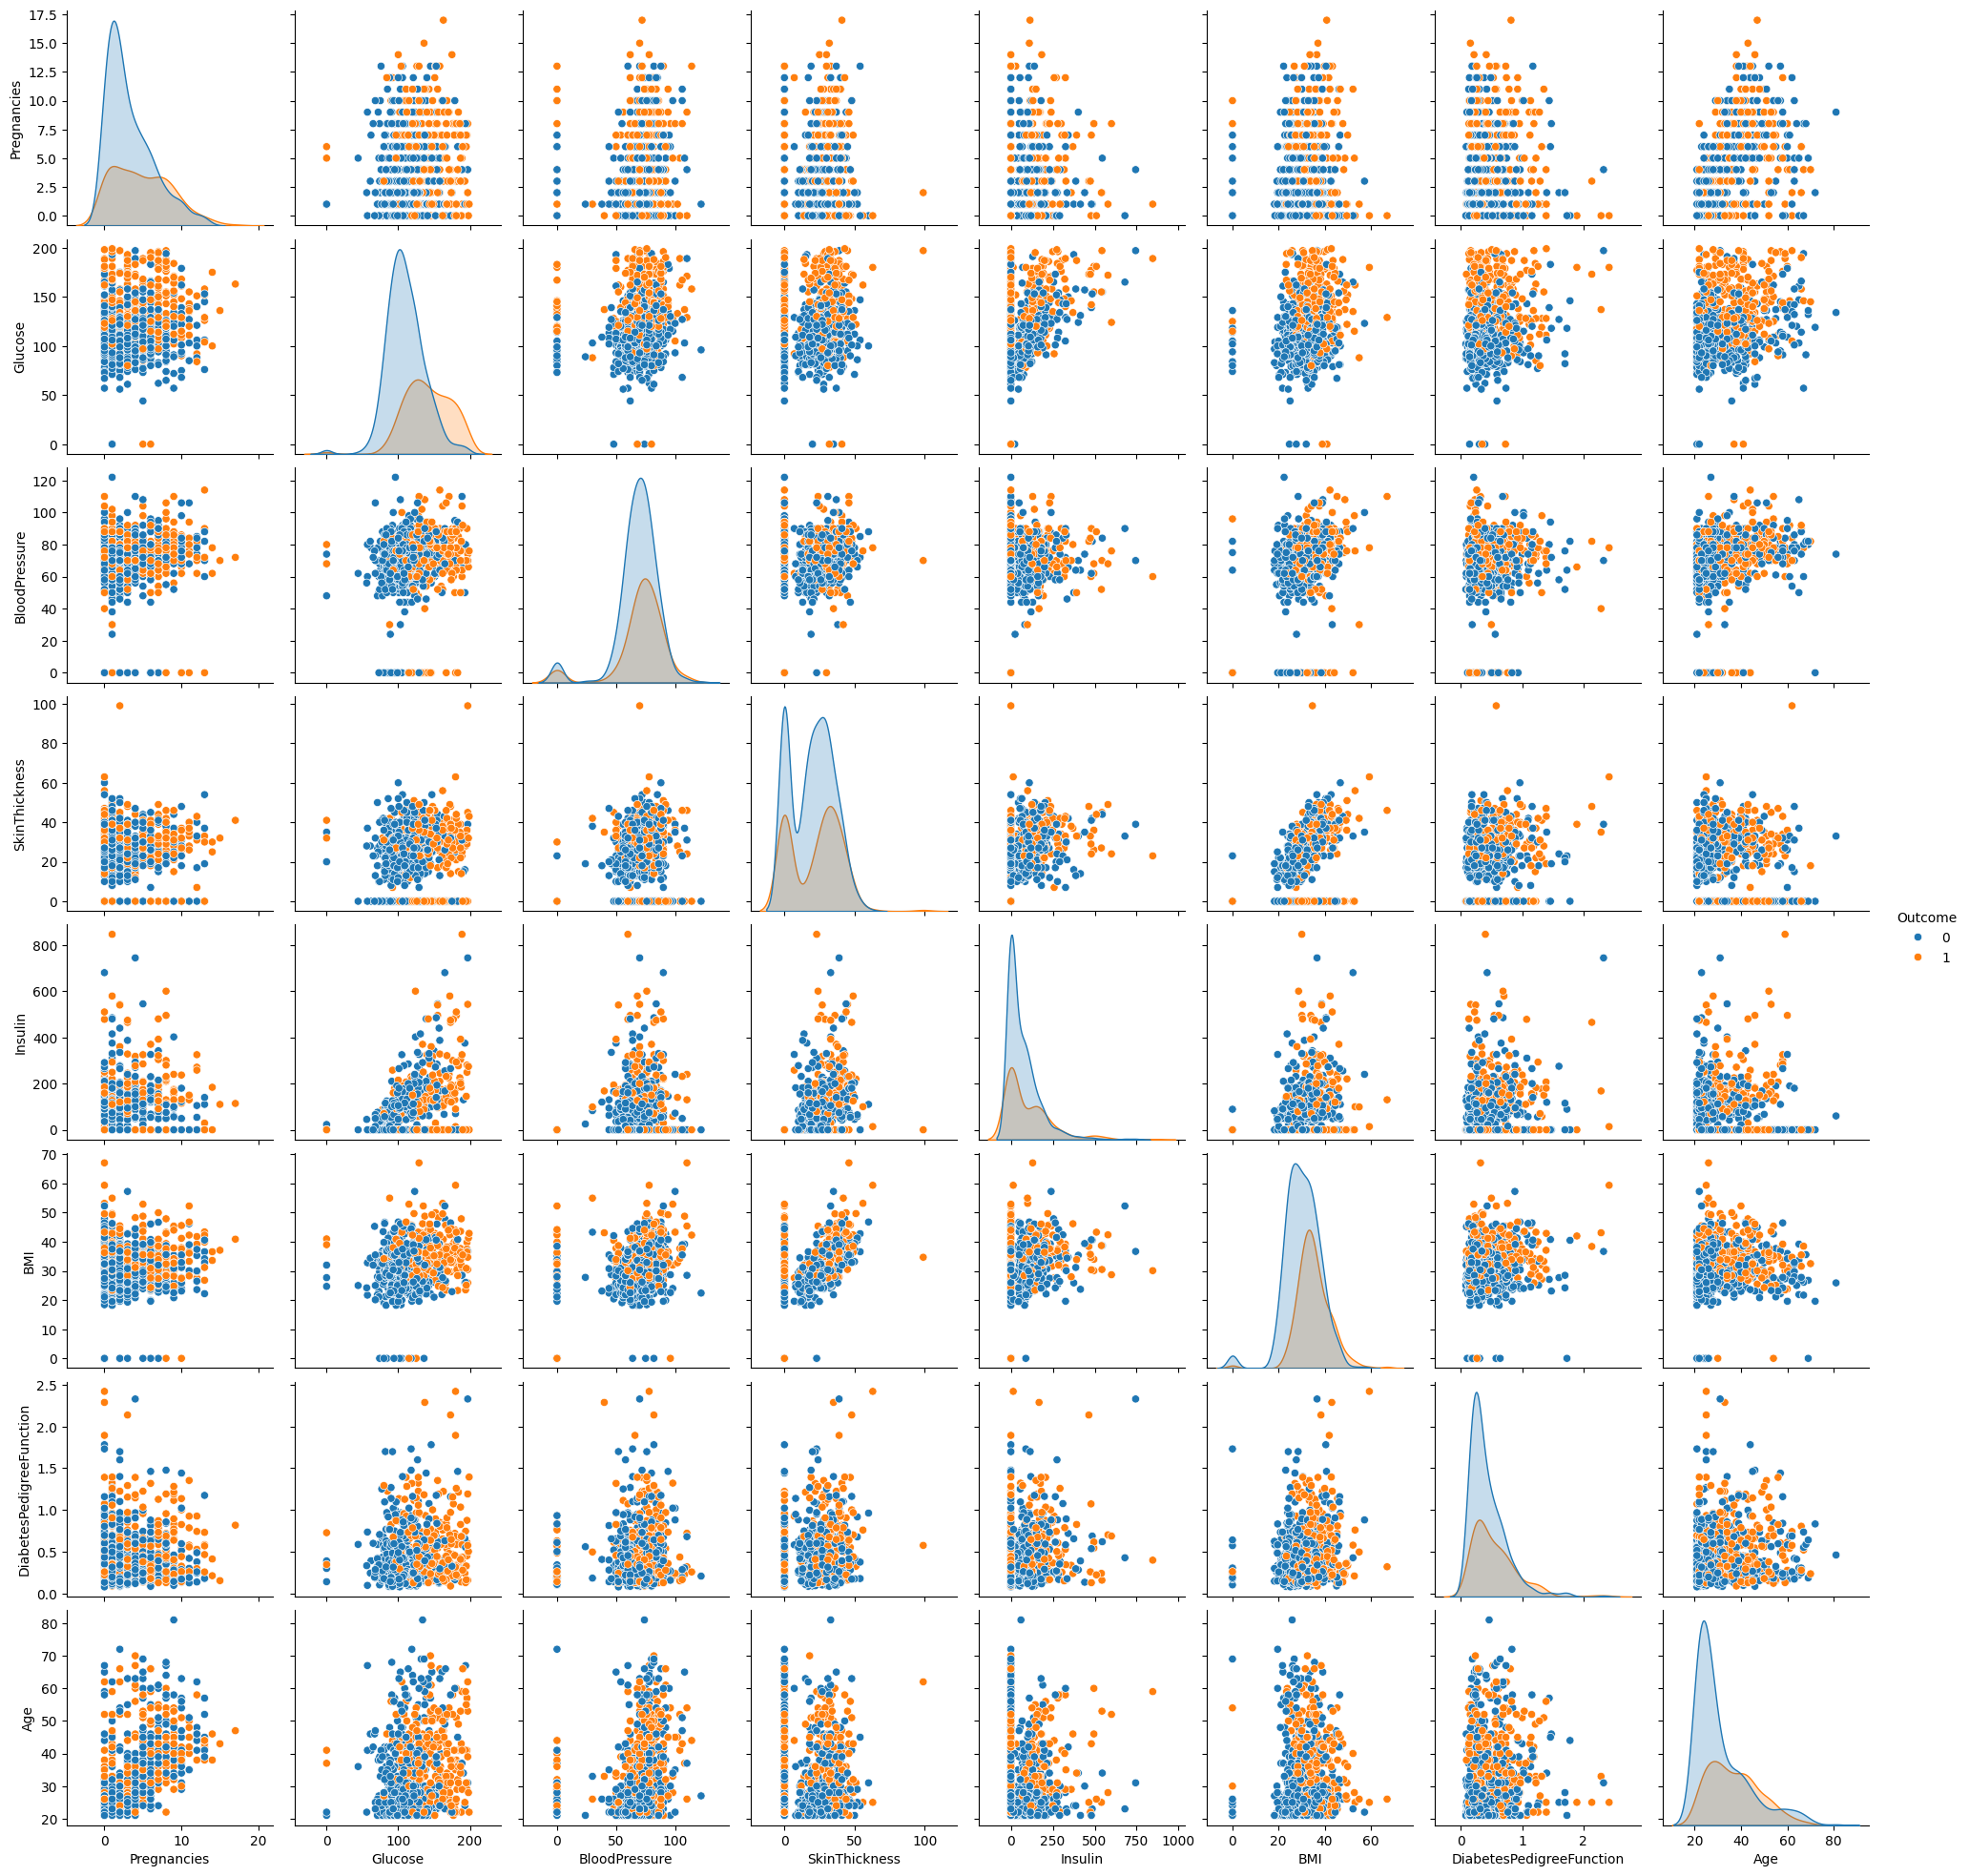

In [35]:
sn.pairplot(df,hue='Outcome')

 With hue='Outcome', diabetic (1) and non-diabetic (0) patients are colored differently. This helps us immediately see which features best separate the two classes — crucial insight before building a classifier.

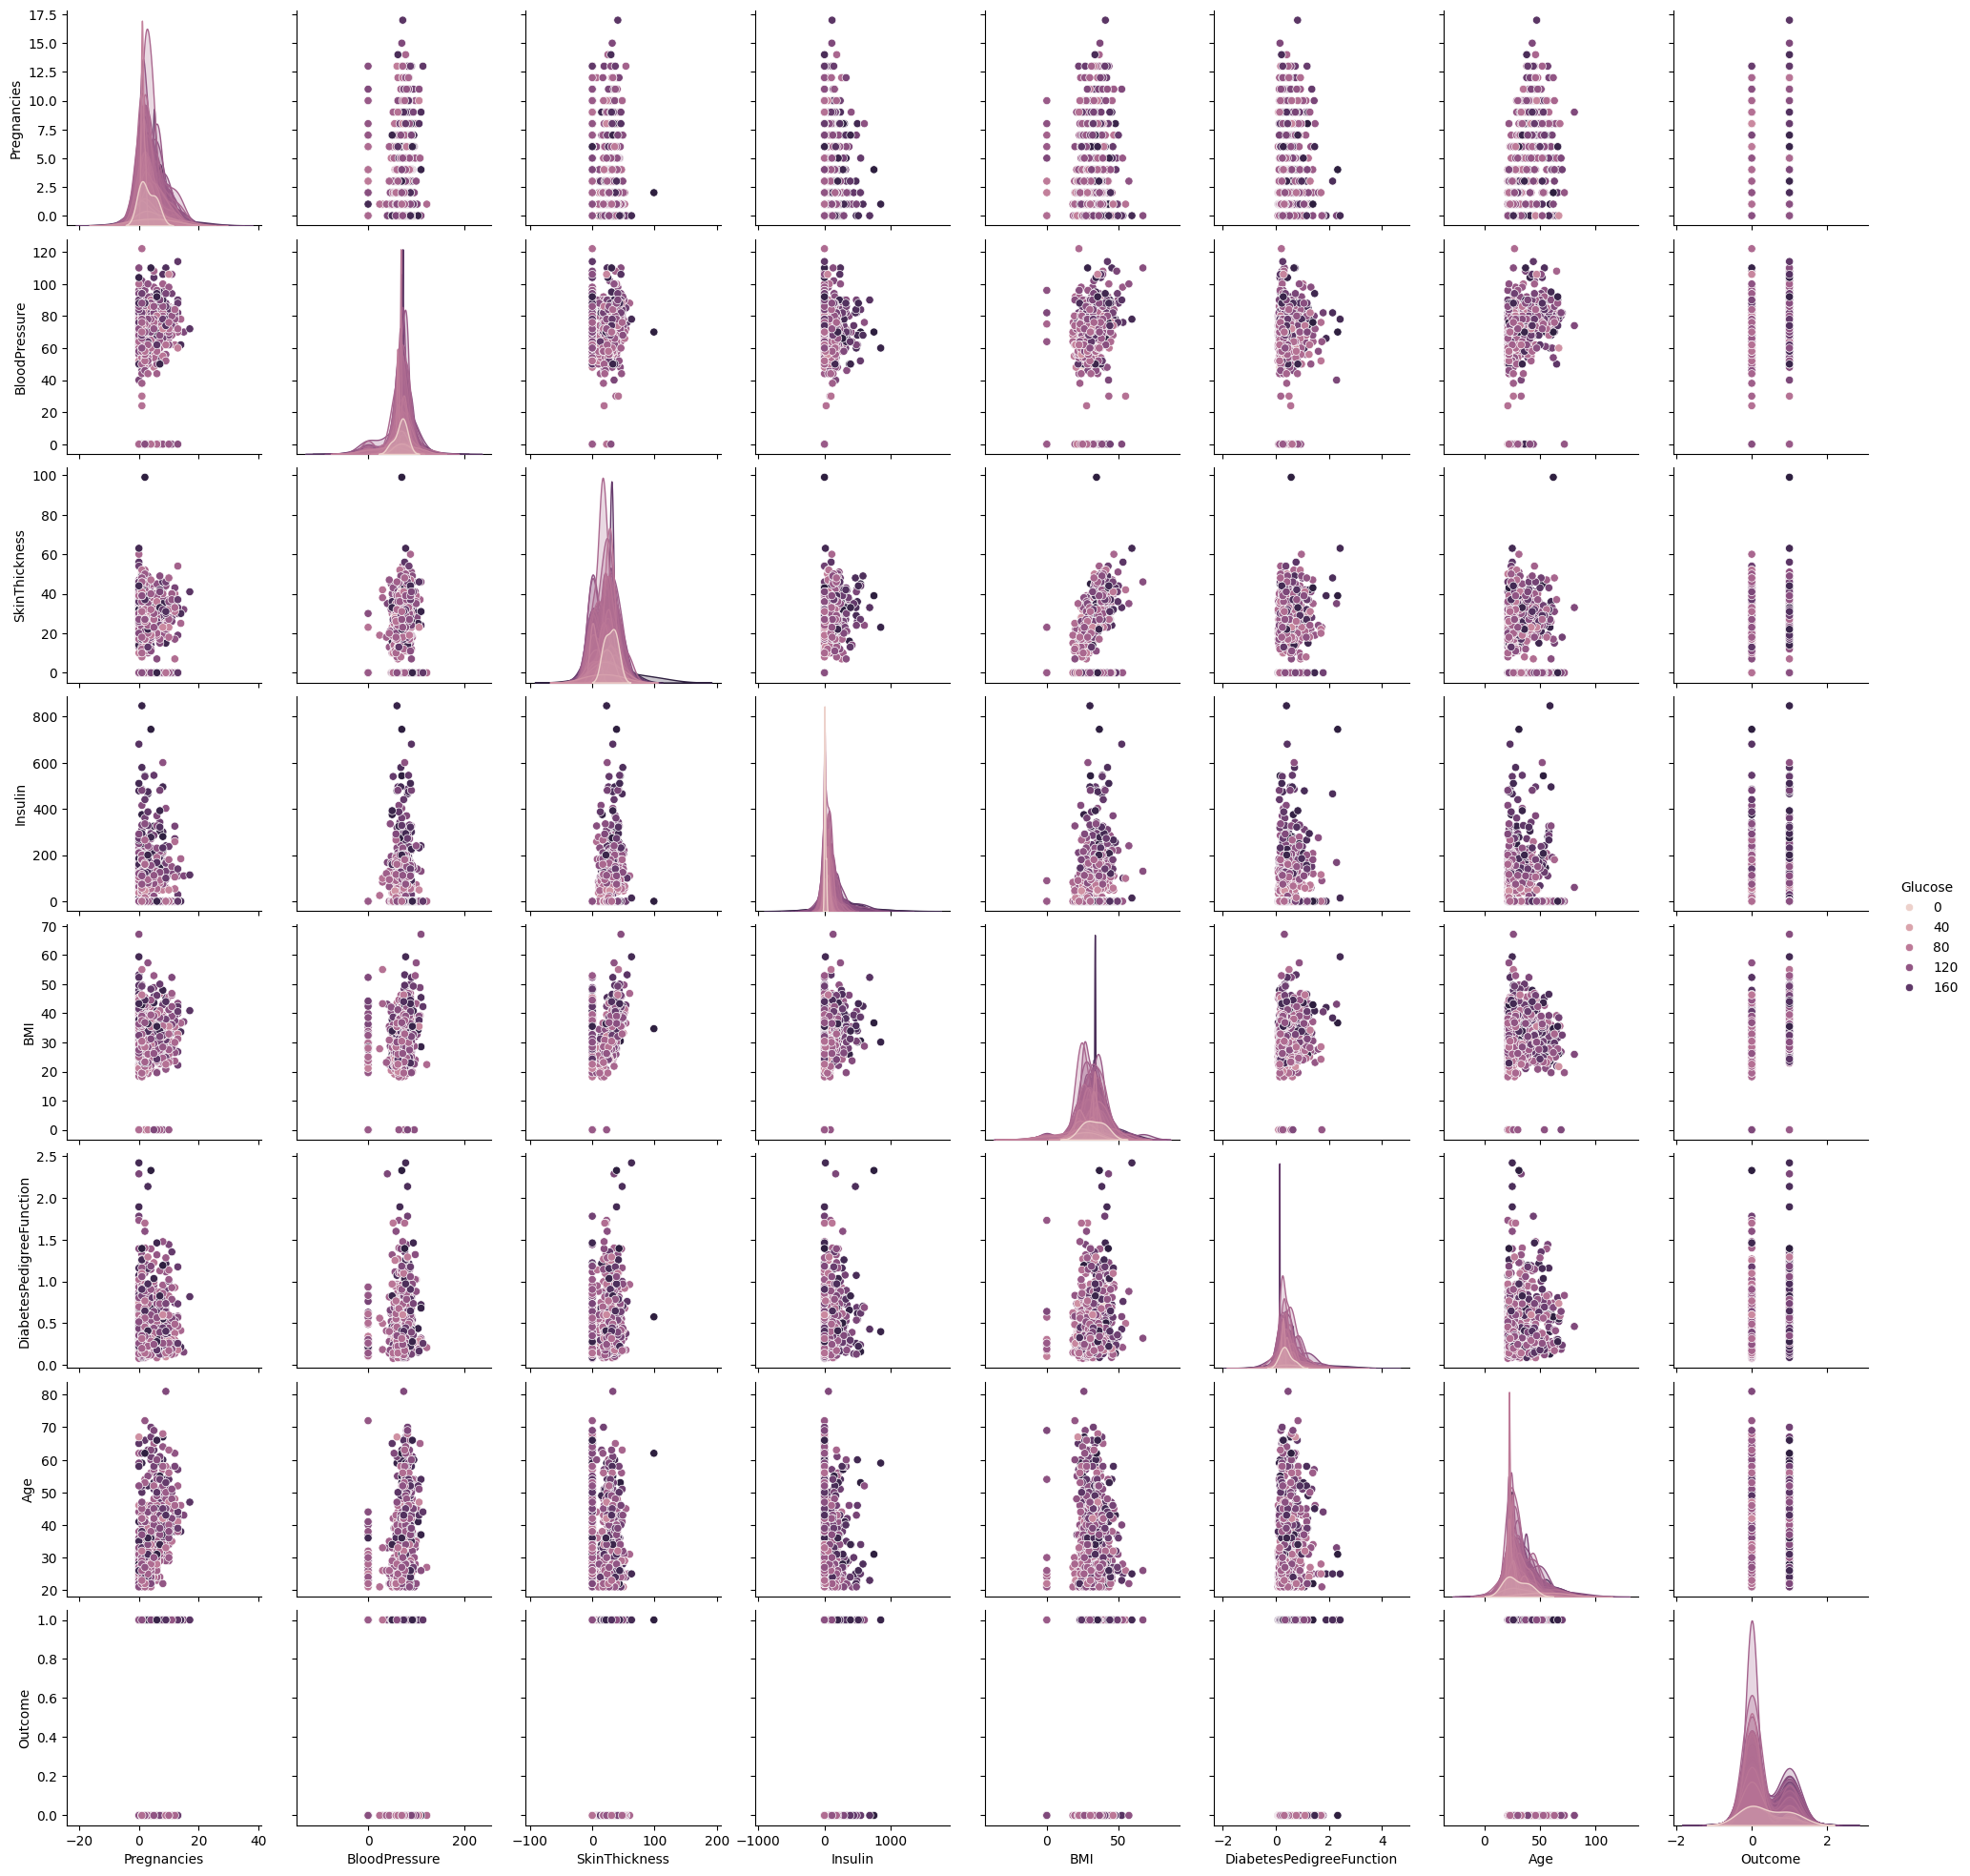

In [36]:
sn.pairplot(df,hue='Glucose')